In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file you just uploaded
try:
    df = pd.read_csv('/Customer-Churn-Records.csv')
    print("✅ SUCCESS: Dataset is loaded and ready!")

    # 1. Inspect the "Face" of the data
    display(df.head())

    # 2. Check for missing values (The Project 1 Rhythm)
    print("\n--- Data Info ---")
    df.info()

except FileNotFoundError:
    print("❌ Error: I can't find the file. Did you upload it to the sidebar folder?")

✅ SUCCESS: Dataset is loaded and ready!


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null 

In [8]:
# 1. Drop columns that don't help with patterns
# We keep 'Exited' as our target
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(cols_to_drop, axis=1)

# 2. One-Hot Encoding for categorical variables
# This handles Geography, Gender, and Card Type
df_final = pd.get_dummies(df_clean, drop_first=True)

# 3. Define X (Features) and y (Target)
X = df_final.drop('Exited', axis=1)
y = df_final['Exited']

# 4. Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data Prepared!")
print(f"Total Features after Encoding: {X.shape[1]}")
display(X.head(3))

✅ Data Prepared!
Total Features after Encoding: 17


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,1,2,464,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,1,3,456,False,True,False,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,3,377,False,False,False,False,False,False


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Initialize the model
rf = RandomForestClassifier(random_state=42)

# 2. Define the 'Grid' of parameters we want to test
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees
    'max_depth': [None, 10, 20],     # How deep the trees go
    'min_samples_split': [2, 5, 10]  # Minimum data points to split a branch
}

# 3. Setup GridSearchCV
# cv=5 means it will split the data 5 times to ensure results are stable
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 4. Train the grid (This might take a minute!)
grid_search.fit(X_train, y_train)

print("✅ Tuning Complete!")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Training Score: {grid_search.best_score_:.4f}")

✅ Tuning Complete!
Best Parameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Training Score: 0.9985


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1607
           1       1.00      1.00      1.00       393

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- Confusion Matrix ---


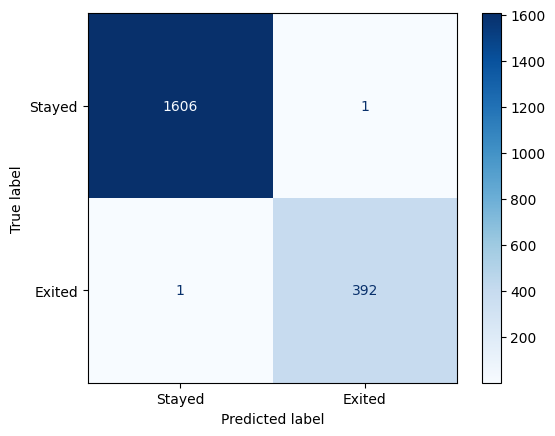

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Use the best model found by the GridSearch
best_rf = grid_search.best_estimator_

# 2. Make predictions on the TEST set
y_pred = best_rf.predict(X_test)

# 3. Print the performance report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 4. Plot the Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited'])
disp.plot(cmap='Blues')
plt.show()

In [11]:
# 1. Drop the 'leaky' columns and the unique IDs
# We drop 'Complain' because it's too closely tied to the outcome
leaky_cols = ['RowNumber', 'CustomerId', 'Surname', 'Complain']
df_honest = df.drop(leaky_cols, axis=1)

# 2. Re-encode and Split
df_final_honest = pd.get_dummies(df_honest, drop_first=True)
X_h = df_final_honest.drop('Exited', axis=1)
y_h = df_final_honest['Exited']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

# 3. Quick Train (using your best params from before to save time)
rf_honest = RandomForestClassifier(n_estimators=50, max_depth=None, min_samples_split=2, random_state=42)
rf_honest.fit(X_train_h, y_train_h)

# 4. Check the NEW reality
y_pred_h = rf_honest.predict(X_test_h)
print("--- NEW Honest Classification Report ---")
print(classification_report(y_test_h, y_pred_h))

--- NEW Honest Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.45      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



In [13]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 58.0 MB/s eta 0:00:00


In [14]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# 1. Load the assets
# We use try/except to give a helpful error if the files aren't exported yet
try:
    model = joblib.load('churn_model.pkl')
    model_columns = joblib.load('churn_columns.pkl')
except:
    st.error("Model files not found! Please run the export cell in your notebook first.")

st.set_page_config(page_title="Bank Churn AI", page_icon="🏦")

st.title("🏦 Bank Customer Churn Predictor")
st.markdown("""
Predict which customers are likely to leave the bank based on their profile.
**Data Scientist Tip:** *Age* and *IsActiveMember* are often the strongest drivers!
""")

# 2. Input Layout
with st.container():
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Customer Profile")
        credit_score = st.slider("Credit Score", 300, 850, 600)
        age = st.number_input("Age", 18, 100, 35)
        tenure = st.slider("Tenure (Years)", 0, 10, 5)
        gender = st.radio("Gender", ["Male", "Female"], horizontal=True)
        geography = st.selectbox("Geography", ["France", "Germany", "Spain"])

    with col2:
        st.subheader("Bank Relationship")
        balance = st.number_input("Account Balance ($)", min_value=0.0, value=50000.0)
        num_products = st.selectbox("Number of Products", [1, 2, 3, 4])
        is_active = st.toggle("Active Member Status", value=True)
        has_card = st.toggle("Has Credit Card", value=True)
        salary = st.number_input("Estimated Salary ($)", min_value=0.0, value=75000.0)

# 3. Prediction Logic
if st.button("Analyze Customer Retention Risk", type="primary", use_container_width=True):
    # Prepare the raw data
    input_dict = {
        'CreditScore': credit_score,
        'Age': age,
        'Tenure': tenure,
        'Balance': balance,
        'NumOfProducts': num_products,
        'HasCrCard': int(has_card),
        'IsActiveMember': int(is_active),
        'EstimatedSalary': salary,
        # Based on your data info, including satisfaction/points if they were in the final model
        'Satisfaction Score': 3,
        'Point Earned': 500
    }

    input_df = pd.DataFrame([input_dict])

    # Handle One-Hot Encoding manually to match our 'df_final'
    input_df[f"Geography_{geography}"] = 1
    input_df[f"Gender_Male"] = 1 if gender == "Male" else 0
    # Note: Drop_first=True was used in training, so France/Female are the 'baseline' (all zeros)

    # Reindex to match the exact training columns order
    input_df = input_df.reindex(columns=model_columns, fill_value=0)

    # Predict
    prob = model.predict_proba(input_df)[0][1]

    # 4. Results Display
    st.divider()
    if prob > 0.5:
        st.error(f"### ⚠️ High Risk: {prob:.1%} probability of leaving")
        st.warning("Recommendation: Offer loyalty incentives or a personal account review.")
    else:
        st.success(f"### ✅ Low Risk: {prob:.1%} probability of leaving")
        st.info("Recommendation: Maintain standard communication.")

Writing app.py


In [16]:
!pip install pyngrok

In [18]:
import os
from google.colab import userdata
from pyngrok import ngrok
import subprocess

# 1. Pull the secret key securely from the notebook's environment
# Change 'NGROK_AUTH' to whatever you named your secret
try:
    NGROK_TOKEN = userdata.get('NGROK_AUTH')
    ngrok.set_auth_token(NGROK_TOKEN)
    print("✅ Secret key loaded successfully!")
except Exception as e:
    print(f"❌ Could not find secret: {e}")

# 2. Clean up any old sessions
ngrok.kill()
os.system("pkill streamlit")

# 3. Launch the App
try:
    # Run Streamlit in the background
    subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

    # Create the public tunnel
    public_url = ngrok.connect(8501).public_url
    print(f"\n🚀 YOUR APP IS LIVE!")
    print(f"Click here to view: {public_url}")
except Exception as e:
    print(f"❌ Connection Failed: {e}")

✅ Secret key loaded successfully!

🚀 YOUR APP IS LIVE!
Click here to view: https://cocciferous-dioicous-gino.ngrok-free.dev
